In [44]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import Draw

import deepmedchem as dmc

In [45]:
DATABASE = "synple-synple-2025-10"
QUERY_SMILES = "C1CC(=O)NC(=O)C1N2C(=O)C3=CC=CC=C3C2=O"
LIMIT = 150
SHORTLIST_MULTIPLIER = 20

In [46]:
result = dmc.search(
    QUERY_SMILES,
    database=DATABASE,
    method="morgan",
    limit=LIMIT,
    shortlist_multiplier=SHORTLIST_MULTIPLIER,
)
print(f"{result.meta.returned} hits from {result.meta.database} (release {result.meta.release}) in {result.meta.elapsed_ms:.0f} ms")

150 hits from synple-synple-2025-10 (release 2025-10.4) in 2078 ms


In [47]:
df = pd.DataFrame(result.to_records())
df = df.dropna(subset=["price"]).reset_index(drop=True)
df["price"] = df["price"].astype(float)
print(f"{len(df)}/{len(result)} hits carry a price estimate")
display(df[["rank", "score", "price", "product_id", "smiles"]].head())

150/150 hits carry a price estimate


,rank,score,price,product_id,smiles
0,1,0.636364,3627.0,41c122099b73c5803ddcf625,O=C1CCC(N2C(=O)c3cccc(CN4CCN(Cc5cccc6c5C(=O)N(...
1,2,0.627907,2627.0,df798cf7ae8cd0575c66bb88,O=C1CCC(N2C(=O)c3ccc(CN4CCN(Cc5ccc6c(c5)C(=O)N...
2,3,0.608696,1727.0,0c4ea340b878c4843a161d16,O=C1CCC(N2C(=O)c3ccc(CN4CCN(Cc5ccccc5)CC4)cc3C...
3,4,0.608696,2627.0,747ed0a3322697da16a9dac1,O=C1CCC(N2C(=O)c3ccc(CN4CCN(C[13c]5[13cH][13cH...
4,5,0.608696,5097.0,9eba12aa913397b1cb0d353f,O=C1CCC(N2C(=O)c3cccc(CN4CCCN(Cc5cccc6c5C(=O)N...


In [48]:
def pareto_mask(frame, score_col="score", price_col="price"):
    order = frame.sort_values([price_col, score_col], ascending=[True, False]).index
    mask = pd.Series(False, index=frame.index)
    best_score = float("-inf")
    for idx in order:
        score = frame.loc[idx, score_col]
        if score > best_score:
            mask[idx] = True
            best_score = score
    return mask


df["pareto_optimal"] = pareto_mask(df)
pareto_df = df[df["pareto_optimal"]].sort_values("score", ascending=False).reset_index(drop=True)
display(pareto_df[["rank", "score", "price", "product_id", "smiles"]])

,rank,score,price,product_id,smiles
0,1,0.636364,3627.0,41c122099b73c5803ddcf625,O=C1CCC(N2C(=O)c3cccc(CN4CCN(Cc5cccc6c5C(=O)N(...
1,2,0.627907,2627.0,df798cf7ae8cd0575c66bb88,O=C1CCC(N2C(=O)c3ccc(CN4CCN(Cc5ccc6c(c5)C(=O)N...
2,3,0.608696,1727.0,0c4ea340b878c4843a161d16,O=C1CCC(N2C(=O)c3ccc(CN4CCN(Cc5ccccc5)CC4)cc3C...
3,18,0.583333,827.0,ce411c9c4b9ef48ca292aa11,O=C1CCC(N2C(=O)c3cccc(C(=O)N4CCC(C5CCN(C(=O)c6...
4,20,0.574468,797.0,3ebb851f624e164f9f44e475,O=C1CCC(N2C(=O)c3ccc(C(=O)N4CCC(C5CCN(C(=O)c6c...
5,130,0.540000,727.0,1b51524d53b7d3a9413024df,O=C1CCC(N2C(=O)c3ccc(C(=O)N4CC5CCC(C4)N5C(=O)c...


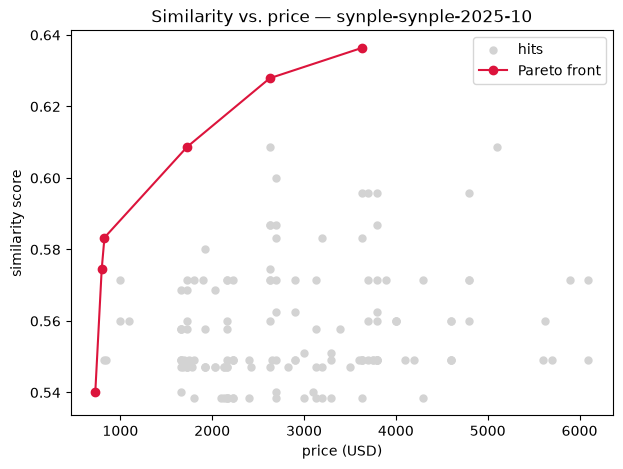

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df["price"], df["score"], s=25, c="lightgray", label="hits", zorder=1)

pareto_sorted = pareto_df.sort_values("price")
ax.plot(pareto_sorted["price"], pareto_sorted["score"], "o-", color="crimson", label="Pareto front", zorder=2)

ax.set_xlabel("price (USD)")
ax.set_ylabel("similarity score")
ax.set_title(f"Similarity vs. price — {DATABASE}")
ax.legend()
plt.show()

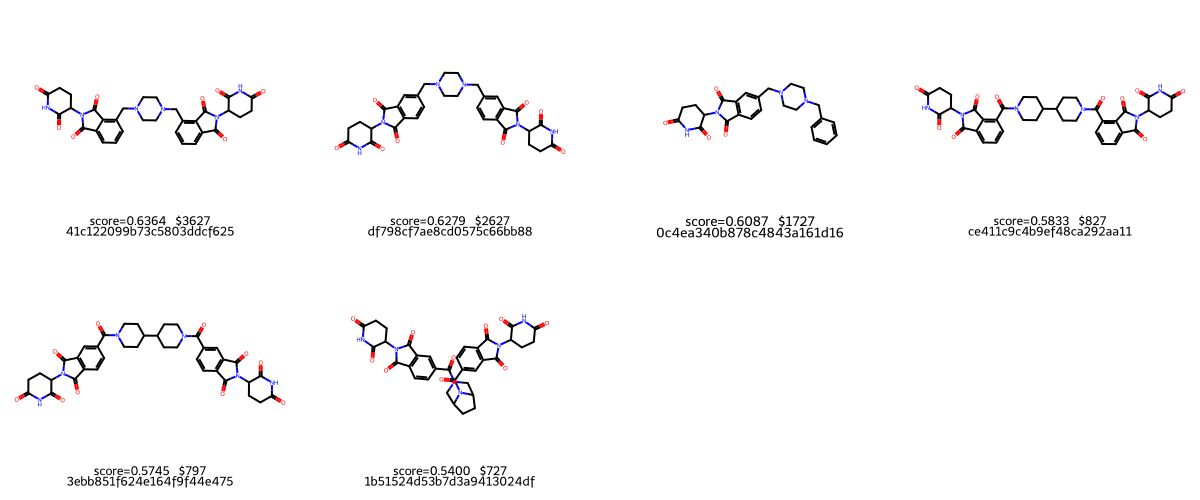

In [50]:
molecules = []
legends = []

for _, row in pareto_df.iterrows():
    mol = Chem.MolFromSmiles(row["smiles"])
    if mol is None:
        continue
    molecules.append(mol)
    legends.append(f"score={row['score']:.4f}  ${row['price']:.0f}\n{row['product_id']}")

Draw.MolsToGridImage(
    molecules,
    molsPerRow=4,
    subImgSize=(300, 250),
    legends=legends,
    useSVG=True,
)